In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import kinematics_v2 as kin
from robot_control import RobotController
import Variables as vb

from defects_id_wrapper import (take_defects_global,    # wrapper to take photos
                                duplicate_filter)       # filter to remove duplicates
from camera_scripts_v2 import  (draw_multiple_debug,    # function to draw debug info on the image
                                init_zed,               # function to initialize the ZED camera
                                WINDOW_NAME_RGB, WINDOW_NAME_MASK)


IP_LAB = "192.168.1.3"
controller = RobotController(ip_address=IP_LAB)
controller.disconnect()
controller.connect()

[12:21:12] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

[12:21:20] INFO     Connected to Listen Node                                                          techman.py:37

In [2]:
controller.default_positioning()

In [3]:
#POSITIONING_POSE = [34, 380, 450, 180, 0, -90]
POSITIONING_POSE = [380, 150, 550, 180, 0, 180]

controller.move_ptp(POSITIONING_POSE)

In [8]:
# initialize the ZED camera
# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

ZED inizializzata.


[453.40585778908485, 91.35804690878147, 167.3797391351403]
[454.7965876556599, 232.7068015247338, 168.7753272517075]


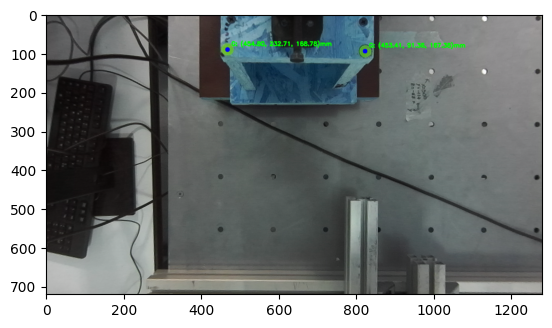

In [9]:
#definiamo le coordinate della camera
ee_pose_global = controller.robot.tcp_coord
camera_pose_ee = vb.CAMERA_POSE_EE

H_ee_to_global = kin.create_homogeneous_matrix(ee_pose_global)
H_cam_to_ee = kin.create_homogeneous_matrix(camera_pose_ee)
H_cam_to_global = H_ee_to_global @ H_cam_to_ee

# prendiamo i defect
defect_list, bgr_image = take_defects_global(runtime, zed, image_zed, point_cloud, H_cam_to_global,
                                            attention_radius=None,
                                            cylindrical_filter=False,
                                            position_filtering=False)

for d in defect_list:
    print(d.pos3d_global.tolist())

#plottiamoli per il debug
debug_img, _ = draw_multiple_debug(bgr_image, defect_list, show_global=True)
plt.imshow(debug_img)

[ 65.9524881  445.67981321 182.60446476]
[-75.96443077 450.7788156  183.173271  ]

WE WANT THIS COORDINATES FOR RESPECTIVELY THE RIGHT AND LEFT MARKER

NUOVE COORDINATE 10 CM PIù VICINE AL ROBOT

[65.24002106997133, 355.93282222165686, 182.099561913089]

[-76.92088141419482, 361.9983227656948, 182.83539856707992]

In [ ]:
'''
PROVA DIFETTO
[  8.28095812 829.2658175  297.49542522]
[  5.34482338 828.79740459 300.03463567]
[  7.23066334 830.26863873 295.7210283 ]

'''

'\nPROVA DIFETTO\n[  8.28095812 829.2658175  297.49542522]\n[  5.34482338 828.79740459 300.03463567]\n[  7.23066334 830.26863873 295.7210283 ]\n\n'

In [ ]:
'''
HELMET CENTER POSITIONS
'''

HC1 = np.array([-0.4518837059320937, 670.7248019800559, 393.64592452452905])
HC2 = np.array([-0.4792674708878333, 672.0780122010136, 394.14232944475583])
HC3 = np.array([-4.49611576989949, 671.6830272942952, 393.2498096590955])
HC4 = np.array([1.6526475400614107, 676.3020702602437, 393.0930261089636])
HC5 = np.array([-1.9276255434854477, 617.476734496335, 381.3471761478071])

HC = np.mean(np.stack(np.array([HC1, HC2, HC3, HC4, HC5])),axis=0)

HC[2] = HC[2] - 200

HC.tolist()

[-1.1404489900286907, 661.6529292463887, 191.09565317703016]

In [ ]:
# le coordinate si prndono così e sono una lista
controller.robot.tcp_coord , controller.robot.joints

([379.99871826171875,
  150.00086975097656,
  550.0006103515625,
  179.99993896484375,
  -0.0002655123535078019,
  179.9999237060547],
 [-176.07350158691406,
  15.393742561340332,
  -90.37496948242188,
  -14.960000038146973,
  -90.1905517578125,
  -85.86833190917969])